In [1]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Dataset path

import os

DATASET_NAME = 'NewPlant'
base_path  = f'/content/drive/MyDrive/Datasets/NewPlant'

train_path = os.path.join(base_path, 'train')
val_path   = os.path.join(base_path, 'valid')
test_path  = os.path.join(base_path, 'test')

print("Base  :", base_path)
print("Train :", train_path)
print("Val   :", val_path)
print("Test  :", test_path)

print("Train exists :", os.path.exists(train_path))
print("Val   exists :", os.path.exists(val_path))
print("Test  exists :", os.path.exists(test_path))

Base  : /content/drive/MyDrive/Datasets/NewPlant
Train : /content/drive/MyDrive/Datasets/NewPlant/train
Val   : /content/drive/MyDrive/Datasets/NewPlant/valid
Test  : /content/drive/MyDrive/Datasets/NewPlant/test
Train exists : True
Val   exists : True
Test  exists : True


In [3]:
# all disease classes
classes = sorted([
    c for c in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, c))
])

print(f"Total Number of Classes: {len(classes)}")
print("\nDisease Classes")
for i, class_name in enumerate(classes, 1):
    print(f"  {i:2d}. {class_name}")

Total Number of Classes: 6

Disease Classes
   1. Bacterial Spot
   2. Early Blight
   3. Healthy
   4. Late Blight
   5. Septoria Leaf Spot
   6. Yellow Leaf Curl Virus


In [4]:
#Count images per class across all splits
import pandas as pd

def count_images_per_class(dataset_path, classes):

    counts = {}
    for class_name in classes:
        class_path = os.path.join(dataset_path, class_name)
        if os.path.exists(class_path):
            counts[class_name] = len([
                f for f in os.listdir(class_path)
                if os.path.isfile(os.path.join(class_path, f))
            ])
        else:
            counts[class_name] = 0
    return counts

train_counts = count_images_per_class(train_path, classes)
val_counts   = count_images_per_class(val_path,   classes)
test_counts  = count_images_per_class(test_path,  classes)

df = pd.DataFrame({
    'Class': classes,
    'Train': [train_counts[c] for c in classes],
    'Val':   [val_counts[c]   for c in classes],
    'Test':  [test_counts[c]  for c in classes],
})
df['Total'] = df['Train'] + df['Val'] + df['Test']

print("Image Distribution Across Classes \n")
print(df.to_string(index=False))

print(f"\nSummary")
print(f"Total Training Images   : {df['Train'].sum()}")
print(f"Total Validation Images : {df['Val'].sum()}")
print(f"Total Test Images       : {df['Test'].sum()}")
print(f"Grand Total             : {df['Total'].sum()}")

Image Distribution Across Classes 

                 Class  Train  Val  Test  Total
        Bacterial Spot   1702  425     6   2133
          Early Blight   1920  480     6   2406
               Healthy   1926  481     4   2411
           Late Blight   1851  463     6   2320
    Septoria Leaf Spot   1745  436     6   2187
Yellow Leaf Curl Virus   1961  490     6   2457

Summary
Total Training Images   : 11105
Total Validation Images : 2775
Total Test Images       : 34
Grand Total             : 13914


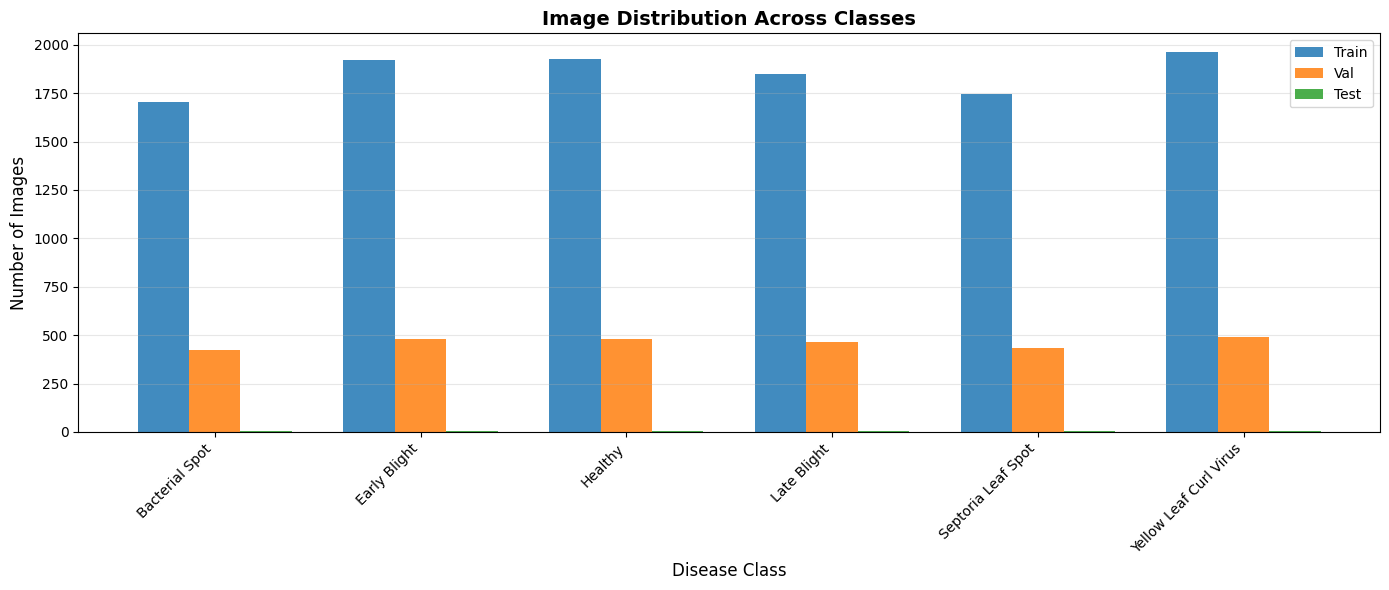

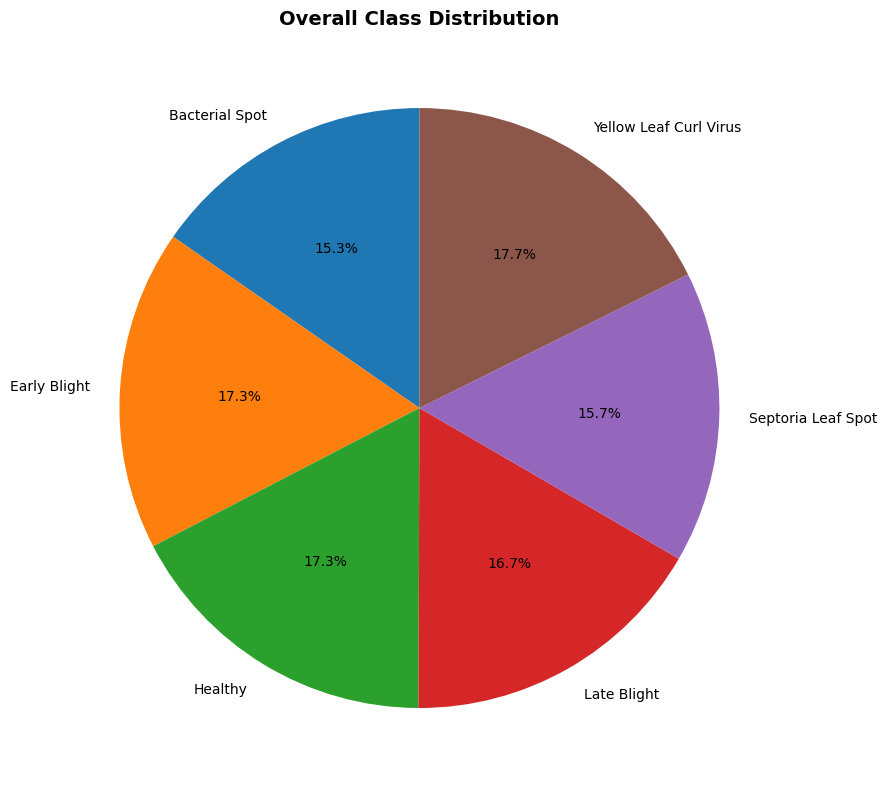

In [5]:
#Visualize class distribution
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(14, 6))
x     = range(len(classes))
width = 0.25

ax.bar([i - width for i in x], df['Train'], width, label='Train', alpha=0.85)
ax.bar(x,                       df['Val'],   width, label='Val',   alpha=0.85)
ax.bar([i + width for i in x], df['Test'],  width, label='Test',  alpha=0.85)

ax.set_xlabel('Disease Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Image Distribution Across Classes', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(9, 9))
ax.pie(df['Total'], labels=df['Class'], autopct='%1.1f%%', startangle=90)
ax.set_title('Overall Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
#Pool all images and apply stratified 80 / 10 / 10 split

from sklearn.model_selection import train_test_split

all_image_paths = []
all_labels      = []

print("Collecting all images from Train / Val / Test folders")
for class_name in classes:
    for split_dir in [train_path, val_path, test_path]:
        class_dir = os.path.join(split_dir, class_name)
        if not os.path.exists(class_dir):
            continue
        for fname in os.listdir(class_dir):
            fpath = os.path.join(class_dir, fname)
            if os.path.isfile(fpath):
                all_image_paths.append(fpath)
                all_labels.append(class_name)

print(f"Total images collected : {len(all_image_paths)}")
print(f"Total labels collected : {len(all_labels)}")

# 80 / 10 / 10 stratified split
train_images, temp_images, train_labels, temp_labels = train_test_split(
    all_image_paths, all_labels,
    test_size=0.2,
    stratify=all_labels,
    random_state=42,
)

val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images, temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42,
)

print(f"\nNew Split Distribution")
print(f"Training   : {len(train_images):5d}  ({len(train_images)/len(all_image_paths)*100:.1f}%)")
print(f"Validation : {len(val_images):5d}  ({len(val_images)/len(all_image_paths)*100:.1f}%)")
print(f"Test       : {len(test_images):5d}  ({len(test_images)/len(all_image_paths)*100:.1f}%)")
print(f"Total      : {len(train_images) + len(val_images) + len(test_images)}")

# Verify class distribution in new split
train_class_counts = pd.Series(train_labels).value_counts().sort_index()
val_class_counts   = pd.Series(val_labels).value_counts().sort_index()
test_class_counts  = pd.Series(test_labels).value_counts().sort_index()

split_df = pd.DataFrame({
    'Class': classes,
    'Train': [train_class_counts.get(c, 0) for c in classes],
    'Val':   [val_class_counts.get(c,   0) for c in classes],
    'Test':  [test_class_counts.get(c,  0) for c in classes],
})
split_df['Total'] = split_df['Train'] + split_df['Val'] + split_df['Test']

print("\nClass Distribution in New Split")
print(split_df.to_string(index=False))

Total images collected : 13914
Total labels collected : 13914

New Split Distribution
Training   : 11131  (80.0%)
Validation :  1391  (10.0%)
Test       :  1392  (10.0%)
Total      : 13914

Class Distribution in New Split
                 Class  Train  Val  Test  Total
        Bacterial Spot   1706  214   213   2133
          Early Blight   1925  240   241   2406
               Healthy   1929  241   241   2411
           Late Blight   1856  232   232   2320
    Septoria Leaf Spot   1750  218   219   2187
Yellow Leaf Curl Virus   1965  246   246   2457


In [7]:
#Analyze image sizes and formats
import numpy as np
from PIL import Image

def get_image_info(image_paths, sample_size=200):

    widths, heights, formats = [], [], []
    sample = np.random.choice(image_paths, min(sample_size, len(image_paths)), replace=False)
    for path in sample:
        try:
            img = Image.open(path)
            widths.append(img.width)
            heights.append(img.height)
            formats.append(img.format)
        except Exception as e:
            print(f"  Error loading: {path} — {e}")
    return widths, heights, formats

print("Analyzing image properties from training set\n")
widths, heights, formats = get_image_info(train_images, sample_size=200)

print("Image Size Statistics")
print(f"Width  — Min: {min(widths)},  Max: {max(widths)},  Mean: {np.mean(widths):.1f}")
print(f"Height — Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.1f}")

print("\nImage Formats")
print(pd.Series(formats).value_counts().to_string())

unique_sizes = set(zip(widths, heights))
print(f"\nSize Uniformity")
print(f"Unique sizes found: {len(unique_sizes)}")
if len(unique_sizes) == 1:
    print(f"All images are the same size: {unique_sizes.pop()}")
else:
    print(" Images have varying sizes. Top 5:")
    top5 = pd.Series([f"{w}x{h}" for w, h in zip(widths, heights)]).value_counts().head(5)
    print(top5.to_string())


Analyzing image properties from training set

Image Size Statistics
Width  — Min: 256,  Max: 256,  Mean: 256.0
Height — Min: 256, Max: 256, Mean: 256.0

Image Formats
JPEG    200

Size Uniformity
Unique sizes found: 1
All images are the same size: (256, 256)


Displaying sample images from training set...



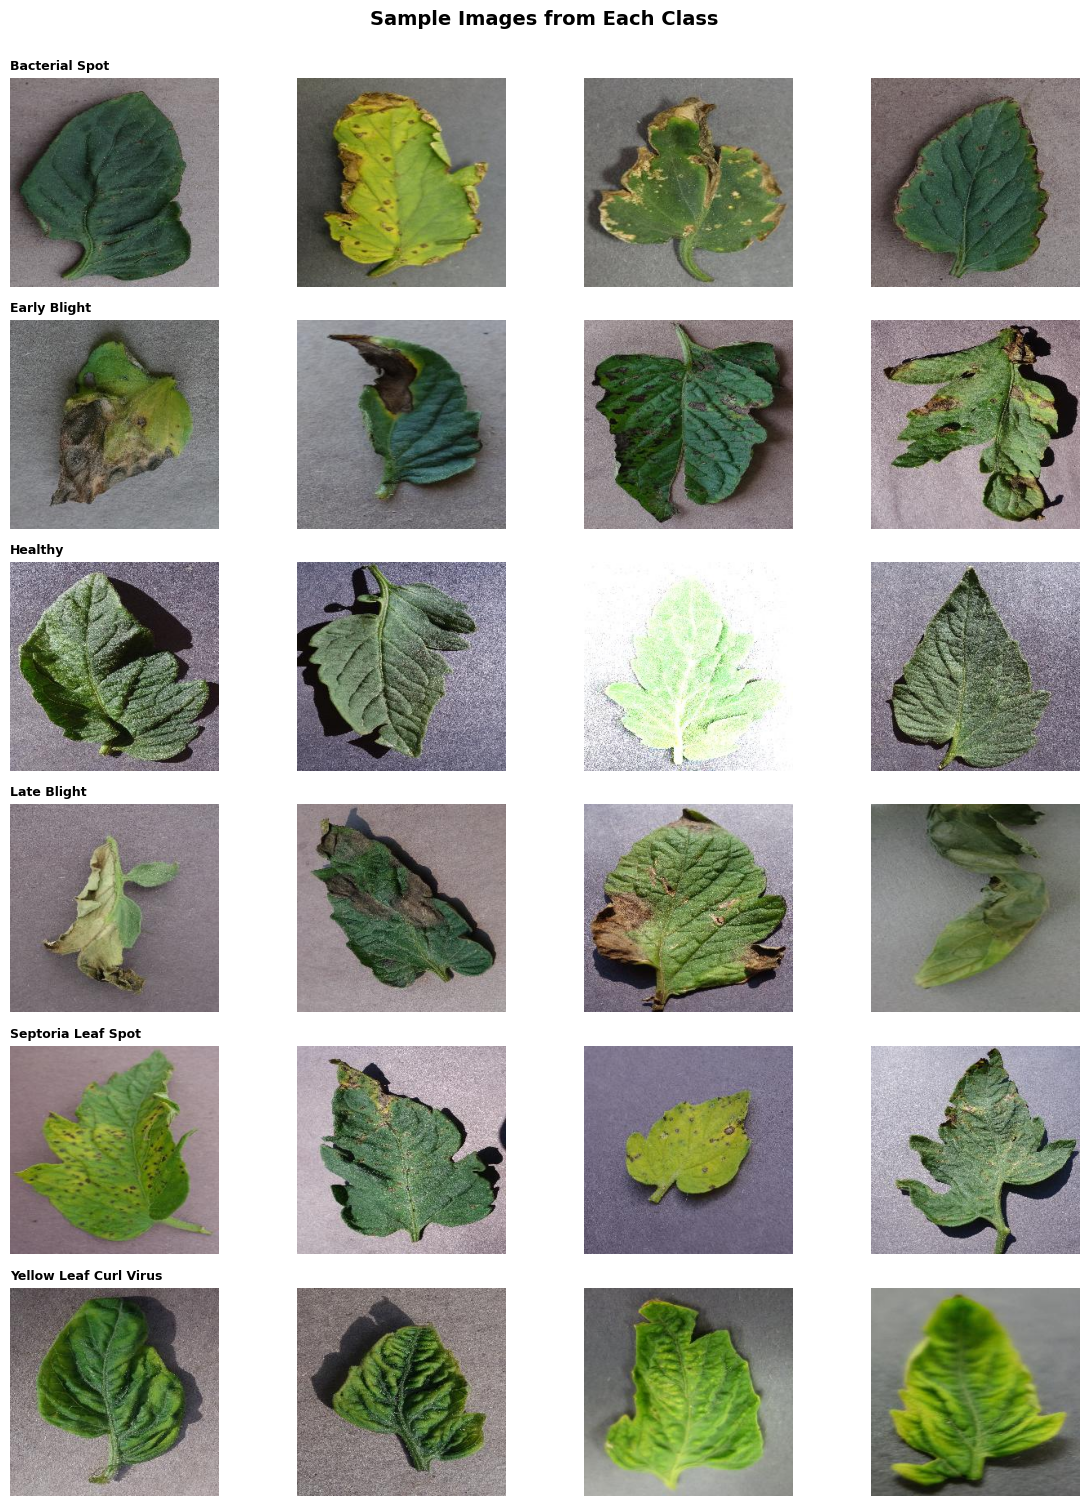

In [8]:
# Display sample images per class
import random

def display_sample_images(image_paths, labels, classes, samples_per_class=4):

    fig, axes = plt.subplots(
        len(classes), samples_per_class,
        figsize=(samples_per_class * 3, len(classes) * 2.5)
    )

    for i, class_name in enumerate(classes):
        class_imgs = [p for p, l in zip(image_paths, labels) if l == class_name]
        samples    = random.sample(class_imgs, min(samples_per_class, len(class_imgs)))

        for j, img_path in enumerate(samples):
            ax = axes[i, j] if len(classes) > 1 else axes[j]
            ax.imshow(Image.open(img_path))
            ax.axis('off')
            if j == 0:
                ax.set_title(class_name, fontsize=9, fontweight='bold', loc='left')

    plt.suptitle('Sample Images from Each Class', fontsize=14, fontweight='bold', y=1.001)
    plt.tight_layout()
    plt.show()

print("Displaying sample images from training set...\n")
display_sample_images(train_images, train_labels, classes, samples_per_class=4)

In [9]:
#PyTorch imports and device setup
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm import tqdm

print("Environment Setup")
print(f"PyTorch Version     : {torch.__version__}")
print(f"Torchvision Version : {torchvision.__version__}")
print(f"CUDA Available      : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device          : {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs      : {torch.cuda.device_count()}")
else:
    print("Running on CPU")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("\nAll libraries imported successfully!")


Environment Setup
PyTorch Version     : 2.10.0+cpu
Torchvision Version : 0.25.0+cpu
CUDA Available      : False
Running on CPU

Using device: cpu

All libraries imported successfully!


In [10]:
# Custom Dataset class
class PlantDiseaseDataset(Dataset):


    def __init__(self, image_paths, labels, transform=None):
        self.image_paths  = image_paths
        self.labels       = labels
        self.transform    = transform

        self.class_names  = sorted(set(labels))
        self.class_to_idx = {name: idx for idx, name in enumerate(self.class_names)}
        self.label_indices = [self.class_to_idx[lbl] for lbl in labels]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img   = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.label_indices[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


_tmp = PlantDiseaseDataset(train_images[:10], train_labels[:10])
print("Class → Index Mapping")
for name, idx in _tmp.class_to_idx.items():
    print(f"  {idx:2d}: {name}")
print(f"\n Dataset class ready. Total classes: {len(_tmp.class_names)}")


Class → Index Mapping
   0: Bacterial Spot
   1: Early Blight
   2: Healthy
   3: Late Blight
   4: Septoria Leaf Spot
   5: Yellow Leaf Curl Virus

 Dataset class ready. Total classes: 6


In [11]:
# Define transforms
from PIL import ImageOps

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMAGE_SIZE    = 224


class AutoContrast:
    def __call__(self, img):
        return ImageOps.autocontrast(img)
    def __repr__(self):
        return "AutoContrast()"


# No augmentation for any split — NewPlant is already augmented
val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    AutoContrast(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transform Defined (no augmentation — dataset already augmented)")
for t in val_test_transform.transforms:
    print(f"  {t}")
print("\nTransform ready!")


BATCH_SIZE = 32


train_dataset = PlantDiseaseDataset(train_images, train_labels, val_test_transform)
val_dataset   = PlantDiseaseDataset(val_images,   val_labels,   val_test_transform)
test_dataset  = PlantDiseaseDataset(test_images,  test_labels,  val_test_transform)

print("=== Dataset Sizes ===")
print(f"Training   : {len(train_dataset)}")
print(f"Validation : {len(val_dataset)}")
print(f"Test       : {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("\n=== DataLoader Configuration ===")
print(f"Batch size         : {BATCH_SIZE}")
print(f"Training batches   : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")
print(f"Test batches       : {len(test_loader)}")

images, labels_batch = next(iter(train_loader))
print(f"\n=== Batch Verification ===")
print(f"Image tensor shape : {images.shape}")
print(f"Labels shape       : {labels_batch.shape}")
print(f"Dtype              : {images.dtype}")
print(f"Value range        : [{images.min():.3f}, {images.max():.3f}]")

print("\nDatasets and DataLoaders ready!")

Transform Defined (no augmentation — dataset already augmented)
  Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
  AutoContrast()
  ToTensor()
  Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

Transform ready!
=== Dataset Sizes ===
Training   : 11131
Validation : 1391
Test       : 1392

=== DataLoader Configuration ===
Batch size         : 32
Training batches   : 348
Validation batches : 44
Test batches       : 44


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



=== Batch Verification ===
Image tensor shape : torch.Size([32, 3, 224, 224])
Labels shape       : torch.Size([32])
Dtype              : torch.float32
Value range        : [-2.118, 2.640]

Datasets and DataLoaders ready!


In [13]:
#Create Datasets and DataLoaders
BATCH_SIZE = 32

train_dataset = PlantDiseaseDataset(train_images, train_labels, val_test_transform)
val_dataset   = PlantDiseaseDataset(val_images,   val_labels,   val_test_transform)
test_dataset  = PlantDiseaseDataset(test_images,  test_labels,  val_test_transform)

print("=== Dataset Sizes ===")
print(f"Training   : {len(train_dataset)}")
print(f"Validation : {len(val_dataset)}")
print(f"Test       : {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("\n=== DataLoader Configuration ===")
print(f"Batch size         : {BATCH_SIZE}")
print(f"Training batches   : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")
print(f"Test batches       : {len(test_loader)}")

# Verify a batch loads correctly
images, labels_batch = next(iter(train_loader))
print(f"\n=== Batch Verification ===")
print(f"Image tensor shape : {images.shape}")   # [32, 3, 224, 224]
print(f"Labels shape       : {labels_batch.shape}")
print(f"Dtype              : {images.dtype}")
print(f"Value range        : [{images.min():.3f}, {images.max():.3f}]")

print("\nDatasets and DataLoaders ready!")


=== Dataset Sizes ===
Training   : 11131
Validation : 1391
Test       : 1392

=== DataLoader Configuration ===
Batch size         : 32
Training batches   : 348
Validation batches : 44
Test batches       : 44

=== Batch Verification ===
Image tensor shape : torch.Size([32, 3, 224, 224])
Labels shape       : torch.Size([32])
Dtype              : torch.float32
Value range        : [-2.118, 2.640]

Datasets and DataLoaders ready!


In [15]:
#Check a random sample for corruption
import random

SAMPLE_RATE = 0.1  # check 10% of each split

def check_and_filter_sampled(image_paths, labels, split_name="", sample_rate=0.1):


    sample_size = max(50, int(len(image_paths) * sample_rate))
    sample_indices = random.sample(range(len(image_paths)), sample_size)

    print(f"\n{split_name} — checking {sample_size}/{len(image_paths)} images ({sample_rate*100:.0f}% sample)...")

    corrupted_in_sample = []
    for i in tqdm(sample_indices, desc=f"Sampling {split_name}"):
        try:
            with Image.open(image_paths[i]) as img:
                img.verify()
            with Image.open(image_paths[i]) as img:
                img.load()
                w, h = img.size
            if w < MIN_IMAGE_SIZE or h < MIN_IMAGE_SIZE:
                raise ValueError(f"Too small: {w}x{h}")
        except Exception as e:
            corrupted_in_sample.append((image_paths[i], str(e)))

    if len(corrupted_in_sample) == 0:
        print(f"  Sample clean — assuming full {split_name} set is OK. Skipping full check.")
        return image_paths, labels
    else:
        print(f"  Found {len(corrupted_in_sample)} issues in sample — running full check...")
        return check_and_filter(image_paths, labels, split_name)

MIN_IMAGE_SIZE = 50

train_images, train_labels = check_and_filter_sampled(train_images, train_labels, 'Train')
val_images,   val_labels   = check_and_filter_sampled(val_images,   val_labels,   'Val')
test_images,  test_labels  = check_and_filter_sampled(test_images,  test_labels,  'Test')

print("\n Corruption check complete!")

# Rebuild datasets and loaders
train_dataset = PlantDiseaseDataset(train_images, train_labels, val_test_transform)
val_dataset   = PlantDiseaseDataset(val_images,   val_labels,   val_test_transform)
test_dataset  = PlantDiseaseDataset(test_images,  test_labels,  val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


Train — checking 1113/11131 images (10% sample)...


Sampling Train: 100%|██████████| 1113/1113 [04:26<00:00,  4.18it/s]


  Sample clean — assuming full Train set is OK. Skipping full check.

Val — checking 139/1391 images (10% sample)...


Sampling Val: 100%|██████████| 139/139 [00:37<00:00,  3.75it/s]


  Sample clean — assuming full Val set is OK. Skipping full check.

Test — checking 139/1392 images (10% sample)...


Sampling Test: 100%|██████████| 139/139 [00:35<00:00,  3.90it/s]

  Sample clean — assuming full Test set is OK. Skipping full check.

 Corruption check complete!


In [16]:
#Class distribution and class weights
from collections import Counter

train_label_counts = Counter(train_labels)

print("=== Class Distribution in Training Set ===")
for class_name in classes:
    count = train_label_counts[class_name]
    pct   = count / len(train_labels) * 100
    print(f"  {class_name:35s}: {count:5d}  ({pct:5.2f}%)")

# Inverse-frequency class weights
total_samples = len(train_labels)
num_classes   = len(classes)
class_weights = {
    c: total_samples / (num_classes * train_label_counts[c])
    for c in classes
}

print("\n=== Class Weights (for loss function) ===")
for class_name in classes:
    print(f"  {class_name:35s}: {class_weights[class_name]:.4f}")

# Tensor for PyTorch loss function
weight_list          = [class_weights[c] for c in sorted(classes)]
class_weights_tensor = torch.FloatTensor(weight_list).to(device)

print(f"\nClass weights tensor:\n  {class_weights_tensor}")

# Balance analysis
max_w    = max(weight_list)
min_w    = min(weight_list)
variance = max_w / min_w

print(f"\n=== Balance Analysis ===")
print(f"Weight variance ratio: {variance:.2f}")
if variance < 1.2:
    print("Dataset is well-balanced.")
else:
    print(f"Imbalance detected (ratio {variance:.2f}). Class weights will help training.")



=== Class Distribution in Training Set ===
  Bacterial Spot                     :  1706  (15.33%)
  Early Blight                       :  1925  (17.29%)
  Healthy                            :  1929  (17.33%)
  Late Blight                        :  1856  (16.67%)
  Septoria Leaf Spot                 :  1750  (15.72%)
  Yellow Leaf Curl Virus             :  1965  (17.65%)

=== Class Weights (for loss function) ===
  Bacterial Spot                     : 1.0874
  Early Blight                       : 0.9637
  Healthy                            : 0.9617
  Late Blight                        : 0.9996
  Septoria Leaf Spot                 : 1.0601
  Yellow Leaf Curl Virus             : 0.9441

Class weights tensor:
  tensor([1.0874, 0.9637, 0.9617, 0.9996, 1.0601, 0.9441])

=== Balance Analysis ===
Weight variance ratio: 1.15
Dataset is well-balanced.


=== Image Quality Check (sample of 200 training images) ===



Analyzing: 100%|██████████| 200/200 [00:46<00:00,  4.33it/s]


=== Quality Statistics ===
Blur Score  — Mean: 4205.90,  Std: 5381.25
Brightness  — Mean: 116.67,  Std: 19.16
Contrast    — Mean: 38.34,  Std: 11.81

=== Quality Issues Found ===
Blurry        :   6  (3.0%)
Too dark      :   0  (0.0%)
Too bright    :   2  (1.0%)
Low contrast  :  56  (28.0%)

=== Overall Quality ===
MODERATE — 32.0% issues. Filtering recommended.


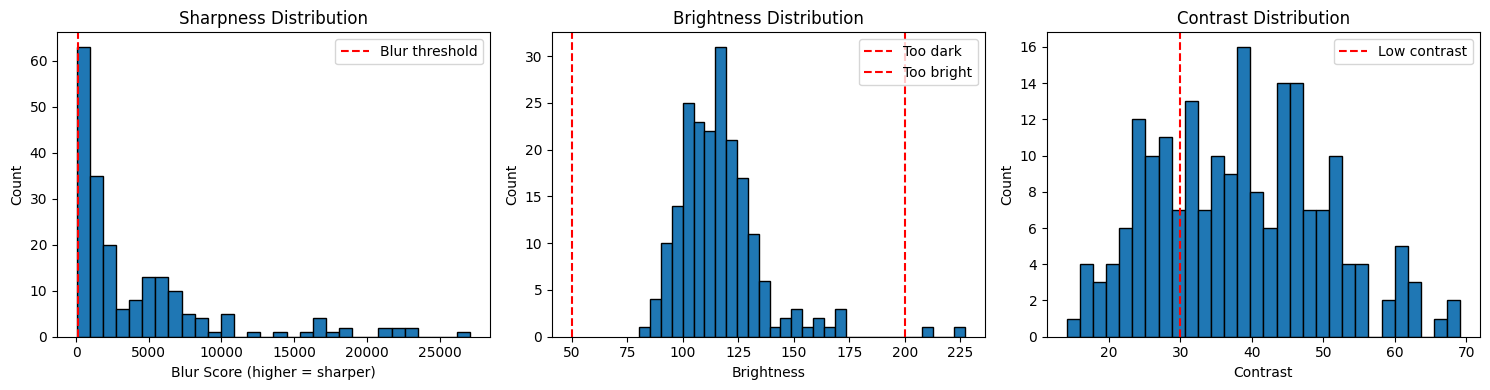

In [17]:
# Image quality check (blur, brightness, contrast)
import cv2

def check_image_quality(img_path):

    try:
        img_array = np.array(Image.open(img_path))
        gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY) if img_array.ndim == 3 else img_array
        return {
            'path':           img_path,
            'blur_score':     cv2.Laplacian(gray, cv2.CV_64F).var(),
            'brightness':     float(np.mean(gray)),
            'contrast':       float(np.std(gray)),
            'is_blurry':      cv2.Laplacian(gray, cv2.CV_64F).var() < 100,
            'is_dark':        np.mean(gray) < 50,
            'is_bright':      np.mean(gray) > 200,
            'is_low_contrast':np.std(gray) < 30,
        }
    except Exception:
        return None

print("=== Image Quality Check (sample of 200 training images) ===\n")
sample_size    = min(200, len(train_images))
sample_indices = np.random.choice(len(train_images), sample_size, replace=False)
sample_paths   = [train_images[i] for i in sample_indices]

quality_results = [r for r in
                   (check_image_quality(p) for p in tqdm(sample_paths, desc="Analyzing"))
                   if r is not None]

blur_scores       = [r['blur_score']  for r in quality_results]
brightness_scores = [r['brightness']  for r in quality_results]
contrast_scores   = [r['contrast']    for r in quality_results]

blurry_images      = [r for r in quality_results if r['is_blurry']]
dark_images        = [r for r in quality_results if r['is_dark']]
bright_images      = [r for r in quality_results if r['is_bright']]
low_contrast_imgs  = [r for r in quality_results if r['is_low_contrast']]

print("=== Quality Statistics ===")
print(f"Blur Score  — Mean: {np.mean(blur_scores):.2f},  Std: {np.std(blur_scores):.2f}")
print(f"Brightness  — Mean: {np.mean(brightness_scores):.2f},  Std: {np.std(brightness_scores):.2f}")
print(f"Contrast    — Mean: {np.mean(contrast_scores):.2f},  Std: {np.std(contrast_scores):.2f}")

print("\n=== Quality Issues Found ===")
n = len(quality_results)
print(f"Blurry        : {len(blurry_images):3d}  ({len(blurry_images)/n*100:.1f}%)")
print(f"Too dark      : {len(dark_images):3d}  ({len(dark_images)/n*100:.1f}%)")
print(f"Too bright    : {len(bright_images):3d}  ({len(bright_images)/n*100:.1f}%)")
print(f"Low contrast  : {len(low_contrast_imgs):3d}  ({len(low_contrast_imgs)/n*100:.1f}%)")

total_issues = len(blurry_images) + len(dark_images) + len(bright_images) + len(low_contrast_imgs)
issue_rate   = total_issues / n * 100

print(f"\n=== Overall Quality ===")
if issue_rate < 5:
    print(f"EXCELLENT — only {issue_rate:.1f}% of images have issues. No filtering needed.")
elif issue_rate < 15:
    print(f"GOOD — {issue_rate:.1f}% minor issues. Optional filtering.")
else:
    print(f"MODERATE — {issue_rate:.1f}% issues. Filtering recommended.")

# Histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(blur_scores, bins=30, edgecolor='black')
axes[0].axvline(100, color='r', linestyle='--', label='Blur threshold')
axes[0].set_xlabel('Blur Score (higher = sharper)')
axes[0].set_ylabel('Count')
axes[0].set_title('Sharpness Distribution')
axes[0].legend()

axes[1].hist(brightness_scores, bins=30, edgecolor='black')
axes[1].axvline(50,  color='r', linestyle='--', label='Too dark')
axes[1].axvline(200, color='r', linestyle='--', label='Too bright')
axes[1].set_xlabel('Brightness')
axes[1].set_ylabel('Count')
axes[1].set_title('Brightness Distribution')
axes[1].legend()

axes[2].hist(contrast_scores, bins=30, edgecolor='black')
axes[2].axvline(30, color='r', linestyle='--', label='Low contrast')
axes[2].set_xlabel('Contrast')
axes[2].set_ylabel('Count')
axes[2].set_title('Contrast Distribution')
axes[2].legend()

plt.tight_layout()
plt.show()


In [18]:
from PIL import Image
import torchvision.transforms.functional as TF

processed_base = '/content/drive/MyDrive/Datasets/NewPlant/processed'

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def save_processed_split(image_paths, labels, split_name):
    save_dir = os.path.join(processed_base, split_name)
    os.makedirs(save_dir, exist_ok=True)
    print(f"\nSaving {split_name}...")

    for idx in tqdm(range(len(image_paths)), desc=split_name):
        img_path   = image_paths[idx]
        class_name = labels[idx]
        class_dir  = os.path.join(save_dir, class_name)
        os.makedirs(class_dir, exist_ok=True)

        img = Image.open(img_path).convert('RGB')
        tensor = val_test_transform(img)

        # Denormalize before saving
        tensor = tensor * IMAGENET_STD + IMAGENET_MEAN
        tensor = tensor.clamp(0, 1)

        fname = os.path.splitext(os.path.basename(img_path))[0] + '.jpg'
        TF.to_pil_image(tensor).save(os.path.join(class_dir, fname), format='JPEG', quality=95)

    print(f"✓ {split_name} saved")



save_processed_split(train_images, train_labels, 'train')
save_processed_split(val_images,   val_labels,   'val')
save_processed_split(test_images,  test_labels,  'test')


Saving train...


train: 100%|██████████| 11131/11131 [42:34<00:00,  4.36it/s]


✓ train saved

Saving val...


val: 100%|██████████| 1391/1391 [06:15<00:00,  3.70it/s]


✓ val saved

Saving test...


test: 100%|██████████| 1392/1392 [06:12<00:00,  3.74it/s]

✓ test saved


In [20]:
import os

def verify_saved_split(split_name):
    split_dir = os.path.join(processed_base, split_name)

    if not os.path.exists(split_dir):
        print(f"{split_name} folder does not exist!")
        return

    print(f"\n{split_name}")
    total = 0
    for class_name in sorted(os.listdir(split_dir)):
        class_dir   = os.path.join(split_dir, class_name)
        count       = len(os.listdir(class_dir))
        total      += count
        print(f"  {class_name:35s}: {count} images")
    print(f"  {'TOTAL':35s}: {total} images")

verify_saved_split('train')
verify_saved_split('val')
verify_saved_split('test')

# Expected
print(f"\n Expected ")
print(f"  train : {len(train_images)} images")
print(f"  val   : {len(val_images)} images")
print(f"  test  : {len(test_images)} images")


train
  Bacterial Spot                     : 1703 images
  Early Blight                       : 1925 images
  Healthy                            : 1929 images
  Late Blight                        : 1851 images
  Septoria Leaf Spot                 : 1745 images
  Yellow Leaf Curl Virus             : 1965 images
  TOTAL                              : 11118 images

val
  Bacterial Spot                     : 214 images
  Early Blight                       : 240 images
  Healthy                            : 241 images
  Late Blight                        : 232 images
  Septoria Leaf Spot                 : 218 images
  Yellow Leaf Curl Virus             : 246 images
  TOTAL                              : 1391 images

test
  Bacterial Spot                     : 213 images
  Early Blight                       : 241 images
  Healthy                            : 241 images
  Late Blight                        : 232 images
  Septoria Leaf Spot                 : 219 images
  Yellow Leaf Curl Viru